## 1. Klasifikasi Flynn

In [1]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


A. Operasi `arr + arr` pada NumPy array >>| SIMD |>> Satu instruksi operasi penjumlahan diterapkan ke banyak elemen array secara bersamaan melalui vectorization. 

B. Program Python biasa yang membaca file lalu memproses baris demi baris tanpa threading/multiprocessing >>| SISD |>> Satu aliran instruksi bekerja pada satu aliran data secara berurutan. 

C. Cluster komputer yang setiap node menjalankan simulasi cuaca berbeda untuk wilayah berbeda secara independen >>| MIMD |>> Banyak prosesor/node menjalankan instruksi dan data yang berbeda secara independen. 

## 2. Analisis Amdahi

Rumus speedup teoritis:

$$
S(N) = \frac{1}{(1-P)+\frac{P}{N}}
$$

Dengan proporsi paralel `P = 0.85`.

## A. Hitung speedup teoritis

In [4]:
def amdahl_speedup(P, N):
    """Menghitung speedup teoritis berdasarkan Hukum Amdahl."""
    return 1 / ((1 - P) + (P / N))

P = 0.85
N_values = [2, 4, 8, 16, 32, 64]

speedups = [amdahl_speedup(P, N) for N in N_values]

hasil_amdahl = pd.DataFrame({
    'Jumlah Prosesor (N)': N_values,
    'Speedup Teoritis': speedups
})

hasil_amdahl

,Jumlah Prosesor (N),Speedup Teoritis
0,2,1.739130
1,4,2.758621
2,8,3.902439
3,16,4.923077
4,32,5.663717
5,64,6.124402


## B. Buat plot speedup vs N

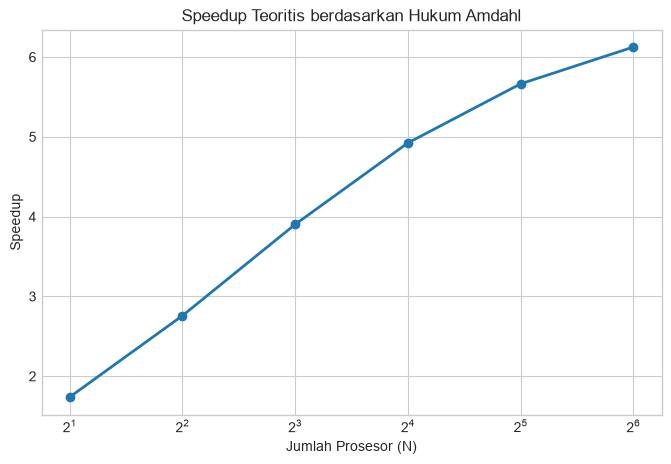

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(N_values, speedups, marker='o', linewidth=2)
plt.title('Speedup Teoritis berdasarkan Hukum Amdahl')
plt.xlabel('Jumlah Prosesor (N)')
plt.ylabel('Speedup')
plt.xticks(N_values)
plt.xscale('log', base=2)
plt.grid(True)
plt.show()

## C. Kesimpulan

Penambahan prosesor mulai memberikan manfaat yang semakin kecil setelah sekitar `N = 16` hingga `N = 32`. Penyebabnya adalah bagian serial sebesar 15% tidak dapat diparalelkan. Ketika jumlah prosesor bertambah, waktu bagian paralel semakin kecil, tetapi waktu bagian serial tetap ada. Akibatnya, speedup mendekati batas maksimum. Jadi, penggunaan prosesor yang sangat banyak tidak menghasilkan peningkatan performa yang sebanding.

## 3. Benchmark Fungsi CPU-Bound

## A. Hitung prima

In [13]:
def hitung_prima(n):
    """Menghitung banyaknya bilangan prima dari 2 sampai n."""
    jumlah_prima = 0

    for angka in range(2, n + 1):
        prima = True

        for pembagi in range(2, int(math.sqrt(angka)) + 1):
            if angka % pembagi == 0:
                prima = False
                break

        if prima:
            jumlah_prima += 1

    return jumlah_prima

## B. Mencari waktu eksekusi

In [10]:
ukuran_input = [5000, 10000, 15000, 20000]
hasil_benchmark = []

for n in ukuran_input:
    mulai = time.perf_counter()
    hasil = hitung_prima(n)
    selesai = time.perf_counter()

    waktu = selesai - mulai
    hasil_benchmark.append({
        'Input n': n,
        'Jumlah Prima': hasil,
        'Waktu Eksekusi (detik)': waktu
    })

tabel_benchmark = pd.DataFrame(hasil_benchmark)
tabel_benchmark

,Input n,Jumlah Prima,Waktu Eksekusi (detik)
0,5000,669,0.010933
1,10000,1229,0.028219
2,15000,1754,0.047133
3,20000,2262,0.037759


## C. Benchmark

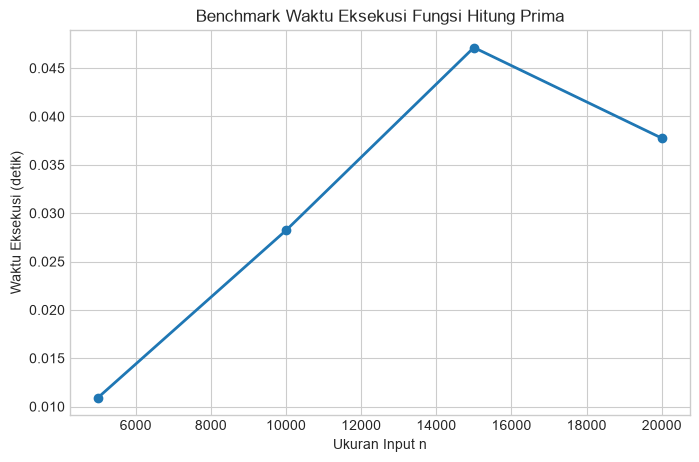

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    tabel_benchmark['Input n'],
    tabel_benchmark['Waktu Eksekusi (detik)'],
    marker='o',
    linewidth=2
)
plt.title('Benchmark Waktu Eksekusi Fungsi Hitung Prima')
plt.xlabel('Ukuran Input n')
plt.ylabel('Waktu Eksekusi (detik)')
plt.grid(True)
plt.show()

## 4. Refleksi Singkat

Hukum Amdahl lebih relevan ketika ukuran masalah relatif tetap dan kita ingin mengetahui seberapa besar percepatan yang dapat diperoleh dengan menambah prosesor. Hukum ini memperlihatkan bahwa bagian serial program akan menjadi batas speedup, sehingga cocok digunakan untuk menganalisis aplikasi yang memiliki proporsi pekerjaan serial yang cukup besar. Contoh nyatanya adalah aplikasi pengolahan citra dengan ukuran gambar tetap. Walaupun jumlah core ditambah, bagian pembacaan file dan penyimpanan hasil tetap membutuhkan waktu.

Sebaliknya, Hukum Gustafson lebih relevan ketika jumlah prosesor bertambah dan ukuran masalah juga dapat diperbesar. Hukum ini digunakan untuk melihat bagaimana sistem paralel mampu menyelesaikan masalah yang lebih besar dalam waktu yang relatif sama. Contoh nyatanya adalah simulasi cuaca atau simulasi ilmiah pada superkomputer. Ketika jumlah node bertambah, wilayah, resolusi, atau jumlah langkah simulasi dapat diperbesar sehingga pekerjaan yang diselesaikan juga meningkat. Dengan demikian, Amdahl menekankan batas speedup pada ukuran masalah tetap, sedangkan Gustafson menekankan peningkatan ukuran masalah yang dapat diselesaikan.